# SMRT sensivitivity study 
### This file contains a sensitivity study of the SMRT model (Picard et al., 2018) to various snowpack parameters. It aims to reproduce the results obtained by Soriot et al., 2022 (https://doi.org/10.1016/j.rse.2022.113061). The source code for the SMRT model is available here: [https://github.com/smrt-model/smrt](https://github.com/smrt-model/smrt)

## Values or ranges used to describe the layers of snow, sea ice, and the ocean in SMRT.

| Medium | Type | Temperature (K) | Thickness | Density (kg/m^3) | Radius (mm) | Stickiness | Liquid water (%) | Salinity (PSU) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Snow** | Wind slab | 230-270 | 1–60 cm | 350 | 0.16 | 0.18 | 0–10 | - |
| **Snow** | Depth hoar | 230-270 | 1–60 cm | 200 | 0.32 | 0.1 | 0 | - |
| **Pure ice** | Superimposed Ice | 230-270 | 0–20 cm | 850 | 1 | 0.2 | - | - |
| **Sea ice** | First-year | 265 | 0.1–1 m | 917 | 0.1 | 0.2 | - | 10 |
| **Sea ice** | Multi-year | 265 | 1–2 m | 850 | 0.1 | 0.2 | - | 1.2 |
| **Ocean** | Arctic | 272 | ∞ | - | - | - | - | 30 |

# I. Ice thickness sensitivity 
In this part, a one-layer first year sea ice with parameter values from the table above is simulated. 

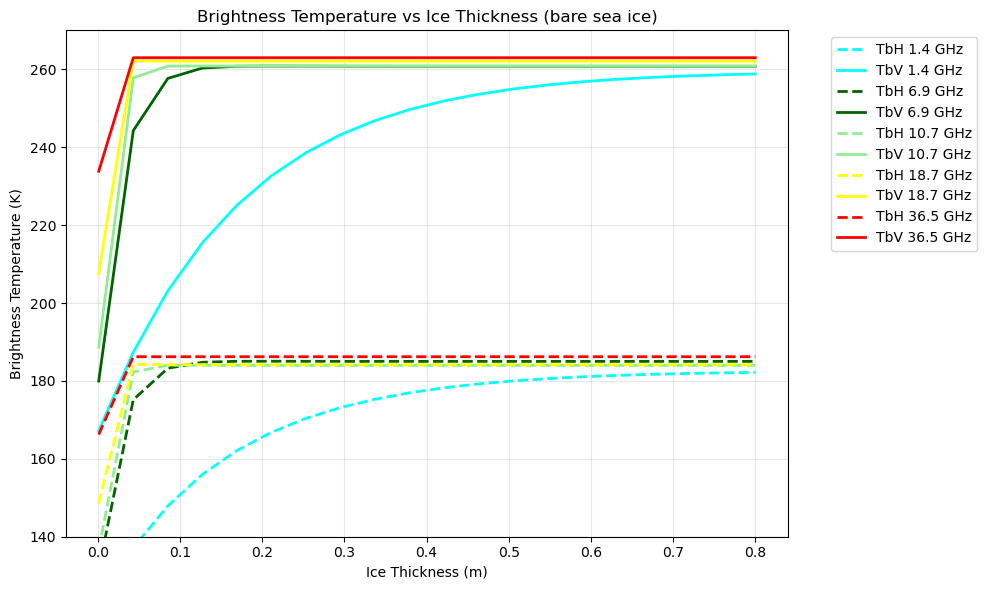

In [4]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
from smrt import make_model, sensor_list, PSU, make_snowpack
from smrt.inputs.make_medium import make_ice_column, make_water_body  
  
first_year_sea_ice_thickness = np.linspace(0.001, 0.8, 20)  # The thickness of the ice layer varies from 0.01 m to 0.8 m  
  
ice_columns = []  
for thickness in first_year_sea_ice_thickness:  
    firstyear_ice = make_ice_column(  
        ice_type="firstyear",  
        thickness=[thickness],  
        microstructure_model="sticky_hard_spheres",  
        density=[917],  
        temperature=[265],  
        radius=[0.1e-3],  
        stickiness=[0.2],  
        salinity=[10 * PSU], 
        brine_volume_fraction=0.11,
        add_water_substrate=False  # we add the substrate manually 
    )  
      
    ocean = make_water_body(  
        temperature=272,  
        salinity=30 * PSU,  
        layer_thickness=1000  # infinite 
    )  
      
    full_snowpack = firstyear_ice  + ocean  
    ice_columns.append(full_snowpack)  
  
sensor = sensor_list.cimr() 

model = make_model("iba", "dort",rtsolver_options=dict(n_max_stream=128))  
  
results = model.run(sensor, ice_columns, snowpack_dimension=('thickness', first_year_sea_ice_thickness))  
  
frequency_colors = {  
    1.4135e9: 'cyan',    # 1.4 GHz  
    6.925e9: 'darkgreen',     # 6.9 GHz    
    10.65e9: 'lightgreen',    # 10.6 GHz  
    18.7e9: 'yellow',         # 18.7 GHz  
    36.5e9: 'red'             # 36.5 GHz  
}  
  
plt.figure(figsize=(10, 6))  
  
# Plot both TbV (solid) and TbH (dashed) for each frequency  
for channel_name, channel_config in sensor.channel_map.items():  
    freq = channel_config['frequency']  
    color = frequency_colors.get(freq,)  
      
    if 'V' in channel_name:  # Vertical polarization - solid lines  
        plt.plot(results.thickness, results.TbV(frequency=freq),   
                color=color, linestyle='-', linewidth=2,   
                label=f"TbV {freq/1e9:.1f} GHz")  
    elif 'H' in channel_name:  # Horizontal polarization - dashed lines  
        plt.plot(results.thickness, results.TbH(frequency=freq),   
                color=color, linestyle='--', linewidth=2,   
                label=f"TbH {freq/1e9:.1f} GHz")  
  
plt.xlabel('Ice Thickness (m)')  
plt.ylabel('Brightness Temperature (K)')  
plt.title('Brightness Temperature vs Ice Thickness (bare sea ice)')  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.grid(True, alpha=0.3)  
plt.ylim(140,270)
plt.tight_layout()  
plt.show()


Then 15 cm of snow, and 1cm of low densisty snow is added on top of first-year sea ice 

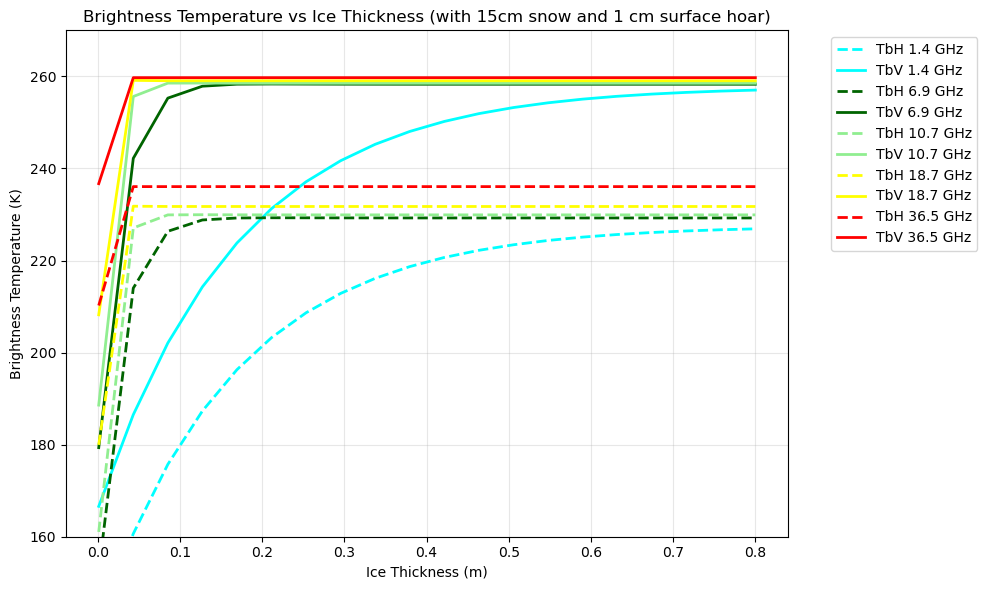

In [5]:
surface_hoar = make_snowpack(  
    thickness=[0.01],  
    microstructure_model="sticky_hard_spheres",  
    density=[150],  #low density
    temperature=[265],  #same temperature as the sea ice, a temperature sensitivity study could be made latter 
    radius=[0.16e-3], #same as wind slab, a radius sensitivity study could be made latter 
    stickiness=[0.18],  #same as wind slab, a stickness sensitivity study could be made latter 
)  

snow = make_snowpack(  
    thickness=[0.15],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[265],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

# Create a list of ice columns with different thicknesses  
ice_columns = []  
for thickness in first_year_sea_ice_thickness:  
    firstyear_ice = make_ice_column(  
        ice_type="firstyear",  
        thickness=[thickness],  
        microstructure_model="sticky_hard_spheres",  
        density=[917],  
        temperature=[265],  
        radius=[0.1e-3],  
        stickiness=[0.2],  
        salinity=[10 * PSU], 
        brine_volume_fraction=0.11,
        add_water_substrate=True,
        water_temperature=272,   
        water_salinity=30 * PSU  
    )  
      
    full_snowpack = surface_hoar + snow + firstyear_ice 
    ice_columns.append(full_snowpack)  
    
sensor = sensor_list.cimr()  
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))  
  

results = model.run(sensor, ice_columns, snowpack_dimension=('thickness', first_year_sea_ice_thickness))  
  
 
frequency_colors = {  
    1.4135e9: 'cyan',    # 1.4 GHz  
    6.925e9: 'darkgreen',     # 6.9 GHz    
    10.65e9: 'lightgreen',    # 10.6 GHz  
    18.7e9: 'yellow',         # 18.7 GHz  
    36.5e9: 'red'             # 36.5 GHz  
}  
  
plt.figure(figsize=(10, 6))  
  
# Plot both TbV (solid) and TbH (dashed) for each frequency  
for channel_name, channel_config in sensor.channel_map.items():  
    freq = channel_config['frequency']  
    color = frequency_colors.get(freq)  
      
    if 'V' in channel_name:  # Vertical polarization - solid lines  
        plt.plot(results.thickness, results.TbV(frequency=freq),   
                color=color, linestyle='-', linewidth=2,   
                label=f"TbV {freq/1e9:.1f} GHz")  
    elif 'H' in channel_name:  # Horizontal polarization - dashed lines  
        plt.plot(results.thickness, results.TbH(frequency=freq),   
                color=color, linestyle='--', linewidth=2,   
                label=f"TbH {freq/1e9:.1f} GHz")  
  
plt.xlabel('Ice Thickness (m)')  
plt.ylabel('Brightness Temperature (K)')  
plt.title('Brightness Temperature vs Ice Thickness (with 15cm snow and 1 cm surface hoar)')  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.grid(True, alpha=0.3)  
plt.tight_layout()  
plt.ylim(160,270)
plt.show()

Adding such a low density layer upon sea ice (with its density of 917  kg/m3) acts as an impedance matching layer by smoothing the transition from sea ice (high permittivity / impedance) to air (low permittivity / impedance).
The simulations at 1.4 GHz evidence the effect of the SIT at this frequency, with increasing TB for increasing SIT up to 50 cm, followed by a saturation for higher thickness, which limit the use of the 1.4 GHz observations to the retrieval of thin sea ice thickness, up to ~ 50 cm.

## result from Soriot's paper 
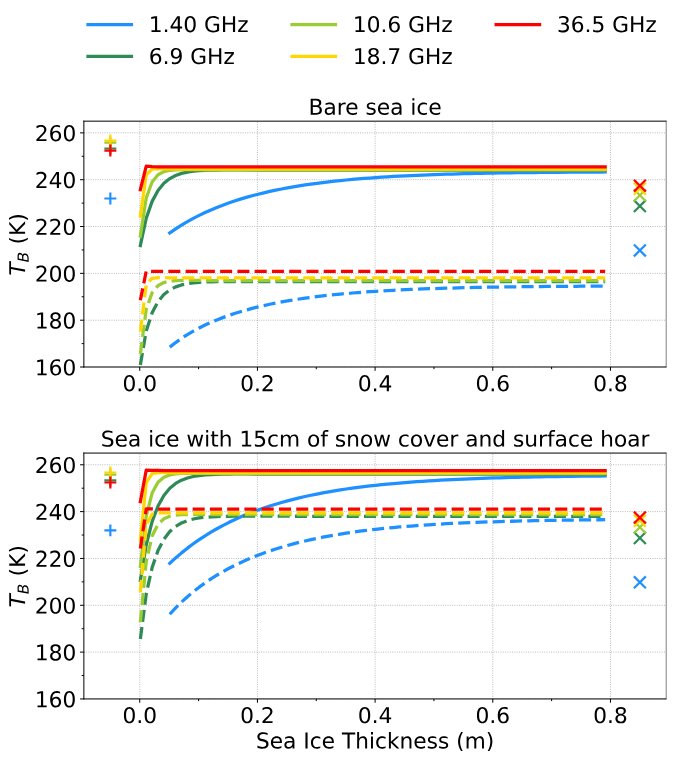

My results show same signature for the different channel, but lower BT af horizontal polarisation, and higher BT at vertical polarisation. 

### Snow temperature sensitivity study 
Additional study, no visible change are observed. 

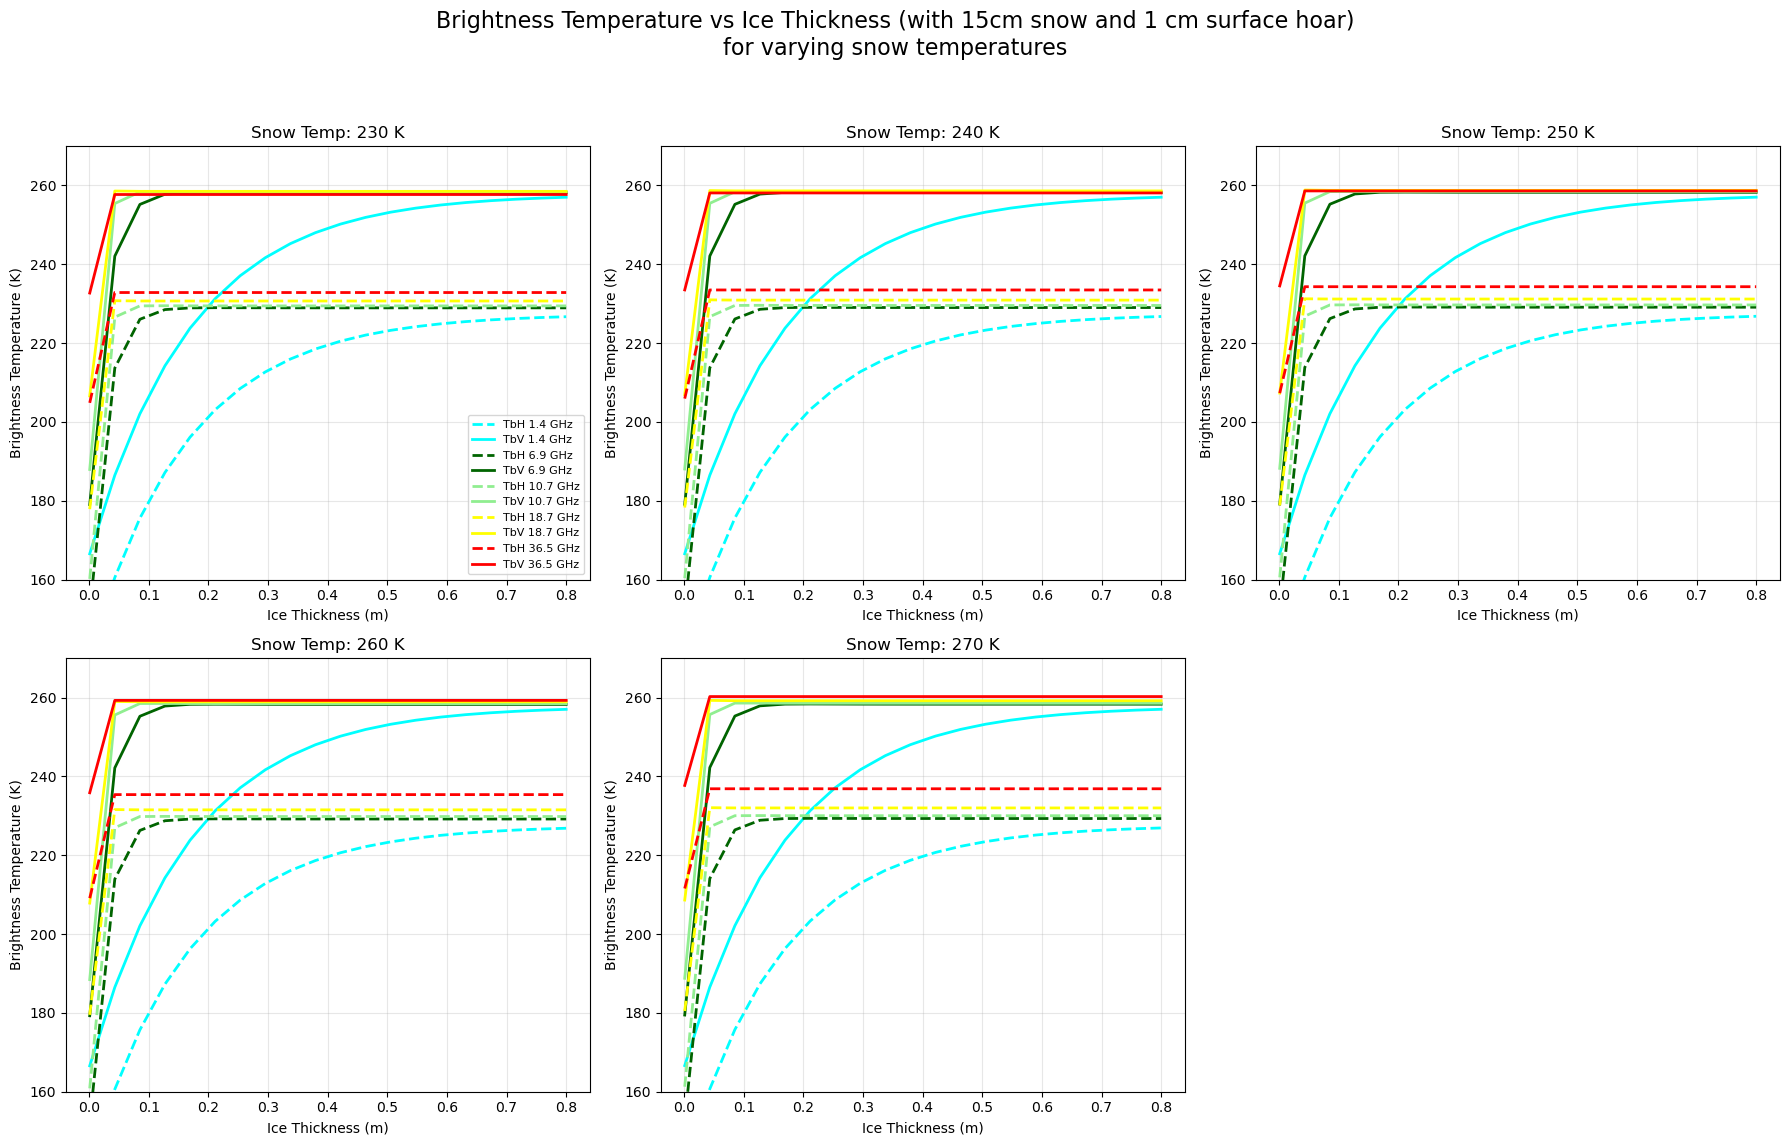

In [8]:
temperatures = [230, 240, 250, 260, 270]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # Flatten to iterate easily with idx

for idx, temp in enumerate(temperatures):
    surface_hoar = make_snowpack(
        thickness=[0.01],
        microstructure_model="sticky_hard_spheres",
        density=[150],  # low density
        temperature=[temp],  # varying temperature
        radius=[0.16e-3],
        stickiness=[0.18],
    )
    
    snow = make_snowpack(
        thickness=[0.15],
        microstructure_model="sticky_hard_spheres",
        density=[350],
        temperature=[temp],  # varying temperature
        radius=[0.16e-3],
        stickiness=[0.18],
    )
    
    # Create a list of ice columns with different thicknesses
    ice_columns = []
    for thickness in first_year_sea_ice_thickness:
        firstyear_ice = make_ice_column(
            ice_type="firstyear",
            thickness=[thickness],
            microstructure_model="sticky_hard_spheres",
            density=[917],
            temperature=[265],
            radius=[0.1e-3],
            stickiness=[0.2],
            salinity=[10 * PSU],
            brine_volume_fraction=0.11,
            add_water_substrate=True,
            water_temperature=272,
            water_salinity=30 * PSU
        )
        full_snowpack = surface_hoar + snow + firstyear_ice
        ice_columns.append(full_snowpack)
    
    sensor = sensor_list.cimr()
    model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))
    results = model.run(sensor, ice_columns, snowpack_dimension=('thickness', first_year_sea_ice_thickness))
    
    frequency_colors = {
        1.4135e9: 'cyan',      # 1.4 GHz
        6.925e9: 'darkgreen',  # 6.9 GHz
        10.65e9: 'lightgreen', # 10.6 GHz
        18.7e9: 'yellow',      # 18.7 GHz
        36.5e9: 'red'          # 36.5 GHz
    }
    
    ax = axes[idx]
    
    # Plot both TbV (solid) and TbH (dashed) for each frequency
    for channel_name, channel_config in sensor.channel_map.items():
        freq = channel_config['frequency']
        color = frequency_colors.get(freq)
        
        if 'V' in channel_name:  # Vertical polarization - solid lines
            ax.plot(results.thickness, results.TbV(frequency=freq), 
                   color=color, linestyle='-', linewidth=2, 
                   label=f"TbV {freq/1e9:.1f} GHz")
        elif 'H' in channel_name:  # Horizontal polarization - dashed lines
            ax.plot(results.thickness, results.TbH(frequency=freq), 
                   color=color, linestyle='--', linewidth=2, 
                   label=f"TbH {freq/1e9:.1f} GHz")
    
    ax.set_xlabel('Ice Thickness (m)')
    ax.set_ylabel('Brightness Temperature (K)')
    ax.set_title(f'Snow Temp: {temp} K')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(160, 270)
    
    # Add legend to each plot or just the first one as before
    if idx == 0:
        ax.legend(loc='lower right', fontsize=8)

# Hide the unused 6th subplot
if len(temperatures) < len(axes):
    axes[-1].axis('off')

plt.suptitle('Brightness Temperature vs Ice Thickness (with 15cm snow and 1 cm surface hoar)\nfor varying snow temperatures', 
             fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# II. Snow depth sensitivity 
A strong decrease of TB with increasing frequency is a sign of scattering process in the radiative transfer.
First, a 2 m layer of multi-year sea ice is simulated, on top of which a snow layer is added, with properties corresponding to a wind slab with small rounded grains. The maximal snow depth simulated is 60 cm, which is close to the maximum observed during field campaigns

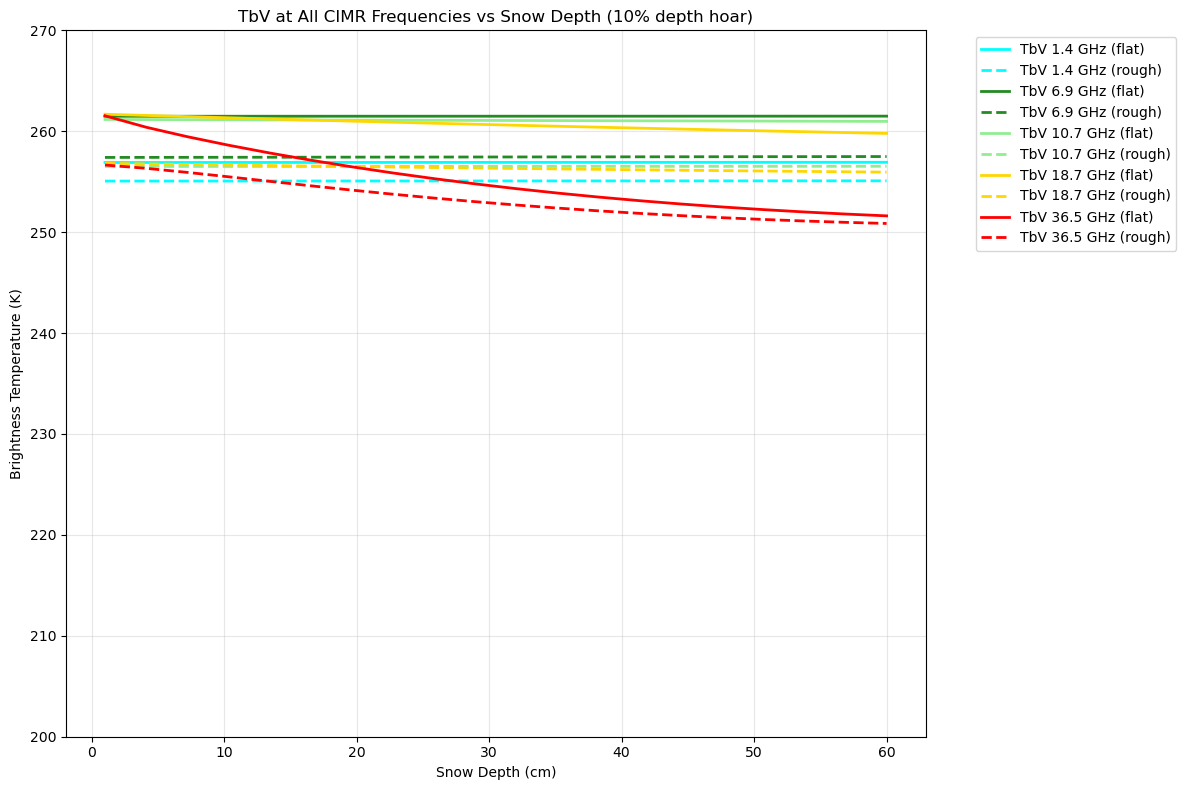

In [12]:
from smrt.core.interface import make_interface  

snow_depths = np.linspace(0.01, 0.6, 20)  

ocean = make_water_body(  
    temperature=272,  
    salinity=30 * PSU,  
    layer_thickness=1000,  
)  
  
flat_interface = make_interface("flat")  
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)

def create_snowpack(total_snow_depth, interface_type):  
    """Create snowpack with wind slab (top) then depth hoar, then interface"""  
        
    depth_hoar_thickness = total_snow_depth * 0.1
    wind_slab_thickness = total_snow_depth * 0.9

    wind_slab = make_snowpack(  
        thickness=[wind_slab_thickness],  
        microstructure_model="sticky_hard_spheres",  
        density=[350],  
        temperature=[265],  
        radius=[0.16e-3], 
        stickiness=[0.18],     
        interface=[flat_interface],
    )  
          
    depth_hoar = make_snowpack(  
        thickness=[depth_hoar_thickness],  
        microstructure_model="sticky_hard_spheres",  
        density=[200],  
        temperature=[265],  
        radius=[0.32e-3],  
        stickiness=[0.10], 
        interface=[flat_interface],
    )  
    
    multiyear_ice = make_ice_column(  
        ice_type="multiyear",  
        thickness=[2],  
        microstructure_model="sticky_hard_spheres",  
        density=[850],  
        temperature=[265],  
        radius=[0.1e-3],  
        stickiness=[0.2],  
        salinity=[1.2 * PSU],  
        brine_volume_fraction=0.05,  
        add_water_substrate=False,  
        interface=interface_type,  
    )  
          
    return wind_slab + depth_hoar + multiyear_ice + ocean  
  

snowpacks_flat = [create_snowpack(depth, flat_interface) for depth in snow_depths]  
snowpacks_rough = [create_snowpack(depth, rough_interface) for depth in snow_depths]  
  
sensor_passive = sensor_list.cimr()  

model = make_model("iba", "dort",rtsolver_options=dict(n_max_stream=128))  
 
results_passive_flat = model.run(sensor_passive, snowpacks_flat,     
                                snowpack_dimension=('thickness', snow_depths))  
results_passive_rough = model.run(sensor_passive, snowpacks_rough,     
                                 snowpack_dimension=('thickness', snow_depths))  
  
frequency_colors = {  
    1.4135e9: 'cyan',        # 1.4 GHz  
    6.925e9: 'forestgreen',      # 6.9 GHz        
    10.65e9: 'lightgreen',      # 10.6 GHz  
    18.7e9: 'gold',       # 18.7 GHz  
    36.5e9: 'red'        # 36.5 GHz  
}  
  
plt.figure(figsize=(12, 8))  
  
for channel_name, channel_config in sensor_passive.channel_map.items():  
    freq = channel_config['frequency']  
    color = frequency_colors.get(freq, '#333333')  
          
    if 'V' in channel_name:  
        # Flat interface (dashed lines)  
        plt.plot(snow_depths * 100, results_passive_flat.TbV(frequency=freq),  
                color=color, linestyle='-', linewidth=2,  
                label=f"TbV {freq/1e9:.1f} GHz (flat)")  
          
        # Rough interface (solid lines)  
        plt.plot(snow_depths * 100, results_passive_rough.TbV(frequency=freq),  
                color=color, linestyle='--', linewidth=2,  
                label=f"TbV {freq/1e9:.1f} GHz (rough)")  
  
plt.xlabel('Snow Depth (cm)')  
plt.ylabel('Brightness Temperature (K)')  
plt.title('TbV at All CIMR Frequencies vs Snow Depth (10% depth hoar)')  
plt.ylim(200, 270)  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.grid(True, alpha=0.3)  
plt.tight_layout()  
plt.show()

To re-conciliate the simulations with the observation, a depth hoar layer with larger crystals (modelled with radius ~0.32 mm and stickiness of 0.10) is thus added in the simulations, below the wind slab. The proportion of depth hoar (40%) used in the simulation is typical of Arctic sea ice.

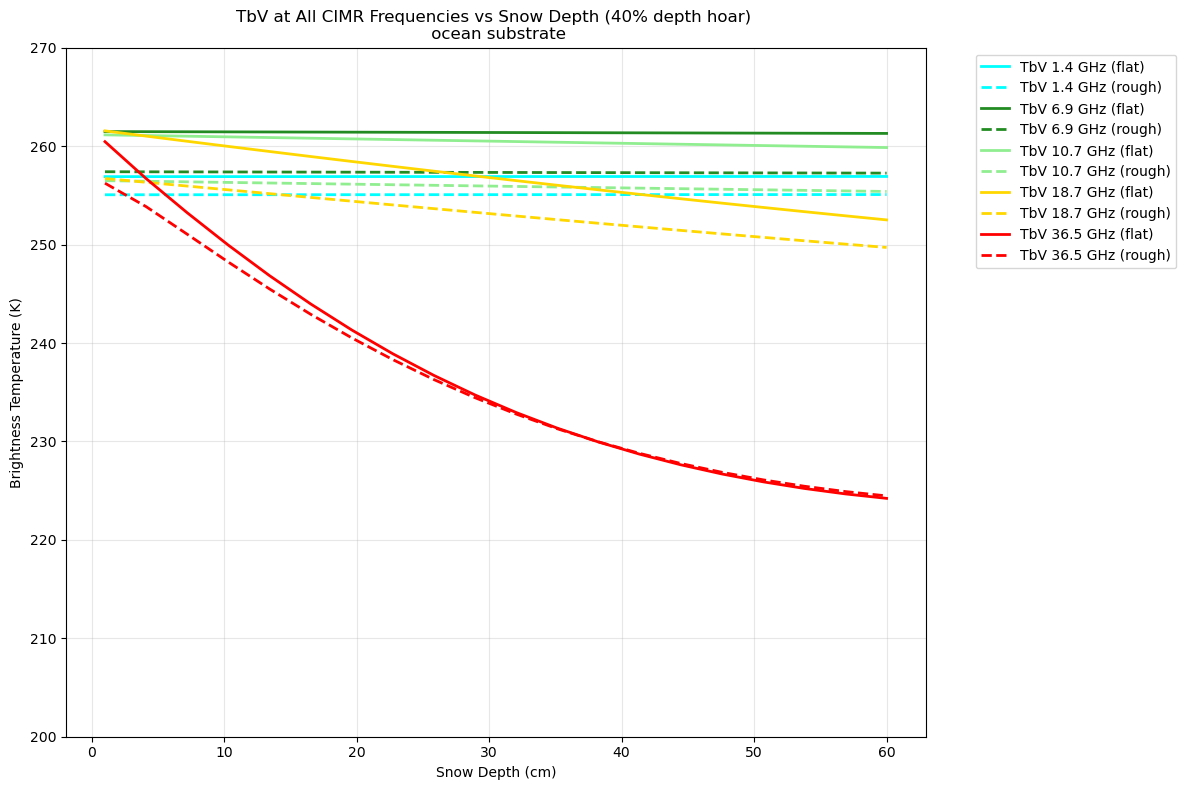

In [13]:

snow_depths = np.linspace(0.01, 0.6, 20)  
  
ocean = make_water_body(  
    temperature=272,  
    salinity=30 * PSU,  
    layer_thickness=1000
)  
 
flat_interface = make_interface("flat")  
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)


def create_snowpack(total_snow_depth, interface_type):  
    depth_hoar_thickness = total_snow_depth * 0.4
    wind_slab_thickness = total_snow_depth * 0.6
          
    wind_slab = make_snowpack(  
        thickness=[wind_slab_thickness],  
        microstructure_model="sticky_hard_spheres",  
        density=[350],  
        temperature=[265],  
        radius=[0.16e-3], 
        stickiness=[0.18],   
        interface=flat_interface,
    )  
          
    depth_hoar = make_snowpack(  
        thickness=[depth_hoar_thickness],  
        microstructure_model="sticky_hard_spheres",  
        density=[200],  
        temperature=[265],  
        radius=[0.32e-3],  
        stickiness=[0.10],   
        interface=flat_interface,
    )  
    
    multiyear_ice = make_ice_column(    
        ice_type="multiyear",    
        thickness=[2],    
        microstructure_model="sticky_hard_spheres",    
        density=[850],    
        temperature=[265],    
        radius=[0.1e-3],    
        stickiness=[0.2],    
        salinity=[1.2 * PSU],    
        brine_volume_fraction=0.05,    
        add_water_substrate=False,    
        interface = interface_type,    
    )
          
    return wind_slab + depth_hoar + multiyear_ice + ocean
  

snowpacks_flat = [create_snowpack(depth, flat_interface) for depth in snow_depths]  
snowpacks_rough = [create_snowpack(depth, rough_interface) for depth in snow_depths]  
  
  
sensor_passive = sensor_list.cimr()  
  

model = make_model("iba", "dort",rtsolver_options=dict(n_max_stream=128))  
  
 
results_passive_flat = model.run(sensor_passive, snowpacks_flat,     
                                snowpack_dimension=('thickness', snow_depths))  
results_passive_rough = model.run(sensor_passive, snowpacks_rough,     
                                 snowpack_dimension=('thickness', snow_depths))  
  
frequency_colors = {  
    1.4135e9: 'cyan',        # 1.4 GHz  
    6.925e9: 'forestgreen',      # 6.9 GHz        
    10.65e9: 'lightgreen',      # 10.6 GHz  
    18.7e9: 'gold',       # 18.7 GHz  
    36.5e9: 'red'        # 36.5 GHz  
}  
  
plt.figure(figsize=(12, 8))  
  
for channel_name, channel_config in sensor_passive.channel_map.items():  
    freq = channel_config['frequency']  
    color = frequency_colors.get(freq, '#333333')  
          
    if 'V' in channel_name:  
        # Flat interface (dashed lines)  
        plt.plot(snow_depths * 100, results_passive_flat.TbV(frequency=freq),  
                color=color, linestyle='-', linewidth=2,  
                label=f"TbV {freq/1e9:.1f} GHz (flat)")  
          
        # Rough interface (solid lines)  
        plt.plot(snow_depths * 100, results_passive_rough.TbV(frequency=freq),  
                color=color, linestyle='--', linewidth=2,  
                label=f"TbV {freq/1e9:.1f} GHz (rough)")  
  
plt.xlabel('Snow Depth (cm)')  
plt.ylabel('Brightness Temperature (K)')  
plt.title('TbV at All CIMR Frequencies vs Snow Depth (40% depth hoar) \n ocean substrate')  
plt.ylim(200, 270)  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.grid(True, alpha=0.3)  
plt.tight_layout()  
plt.show()


Active simulation : backscatter coefficient 

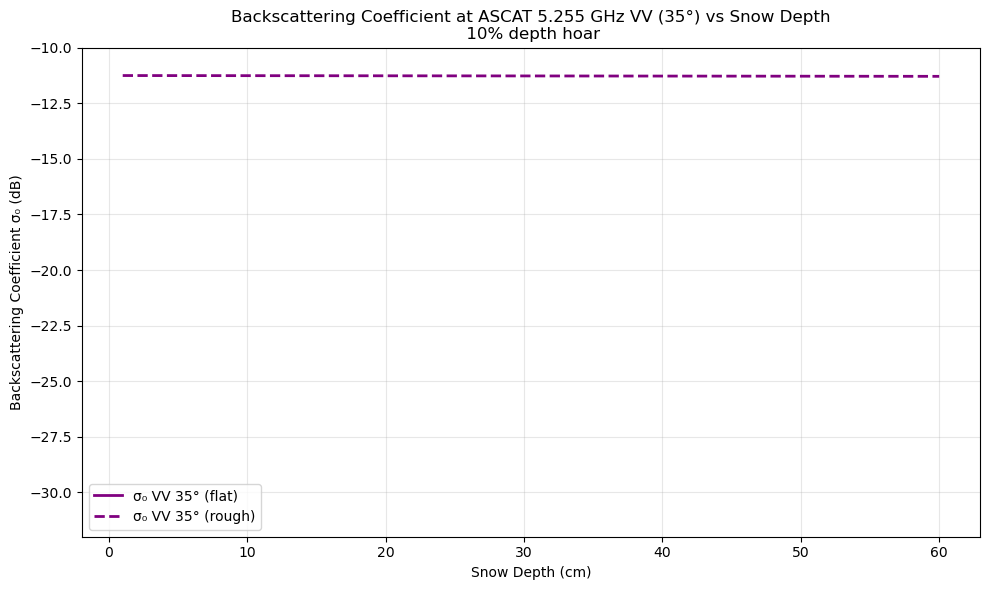

In [29]:
import numpy as np    
import matplotlib.pyplot as plt    
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body    
from smrt.inputs.make_medium import make_ice_column    
from smrt.core.interface import make_interface    
  
snow_depths = np.linspace(0.01, 0.6, 20)      
  
ocean = make_water_body(    
    temperature=272,    
    salinity=30 * PSU,    
    layer_thickness=1000    
)    
      
flat_interface = make_interface("flat")      
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)  
  
def create_snowpack(total_snow_depth, interface_type):    
    """Create snowpack with wind slab (top) then depth hoar, then interface"""    
          
    depth_hoar_thickness = total_snow_depth * 0.1  
    wind_slab_thickness = total_snow_depth * 0.9  
            
    wind_slab = make_snowpack(    
        thickness=[wind_slab_thickness],    
        microstructure_model="sticky_hard_spheres",    
        density=[350],    
        temperature=[265],    
        radius=[0.16e-3],   
        stickiness=[0.18],       
    )    
            
    depth_hoar = make_snowpack(    
        thickness=[depth_hoar_thickness],    
        microstructure_model="sticky_hard_spheres",    
        density=[200],    
        temperature=[265],    
        radius=[0.32e-3],    
        stickiness=[0.10],     
    )    
      
    multiyear_ice = make_ice_column(    
        ice_type="multiyear",    
        thickness=[2],    
        microstructure_model="sticky_hard_spheres",    
        density=[850],    
        temperature=[265],    
        radius=[0.1e-3],    
        stickiness=[0.2],    
        salinity=[1.2 * PSU],    
        brine_volume_fraction=0.05,    
        add_water_substrate=False,  
        interface=interface_type,    
    )    
            
    return wind_slab + depth_hoar + multiyear_ice + ocean 
    
snowpacks_flat = [create_snowpack(depth, flat_interface) for depth in snow_depths]    
snowpacks_rough = [create_snowpack(depth, rough_interface) for depth in snow_depths]    
    
sensor_ascat = sensor_list.ascat(theta=35)  
    
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=64))    
    
# Run with ASCAT sensor    
results_ascat_flat = model.run(sensor_ascat, snowpacks_flat,       
                               snowpack_dimension=('thickness', snow_depths))    
results_ascat_rough = model.run(sensor_ascat, snowpacks_rough,      
                                snowpack_dimension=('thickness', snow_depths))    
    
plt.figure(figsize=(10, 6))    
    

# Flat interface (solid line)
plt.plot(snow_depths * 100, results_ascat_flat.sigmaVV_dB(),    
        color='purple', linestyle='-', linewidth=2,    
        label=f"σ₀ VV 35° (flat)")    
    
# Rough interface (dashed line)
plt.plot(snow_depths * 100, results_ascat_rough.sigmaVV_dB(),    
        color='purple', linestyle='--', linewidth=2,    
        label=f"σ₀ VV 35° (rough)")    
    
plt.xlabel('Snow Depth (cm)')    
plt.ylabel('Backscattering Coefficient σ₀ (dB)')    
plt.title(f'Backscattering Coefficient at ASCAT 5.255 GHz VV (35°) vs Snow Depth\n 10% depth hoar')    
plt.ylim(-32, -10)  
plt.legend(loc='best')    
plt.grid(True, alpha=0.3)    
plt.tight_layout()    
plt.show()

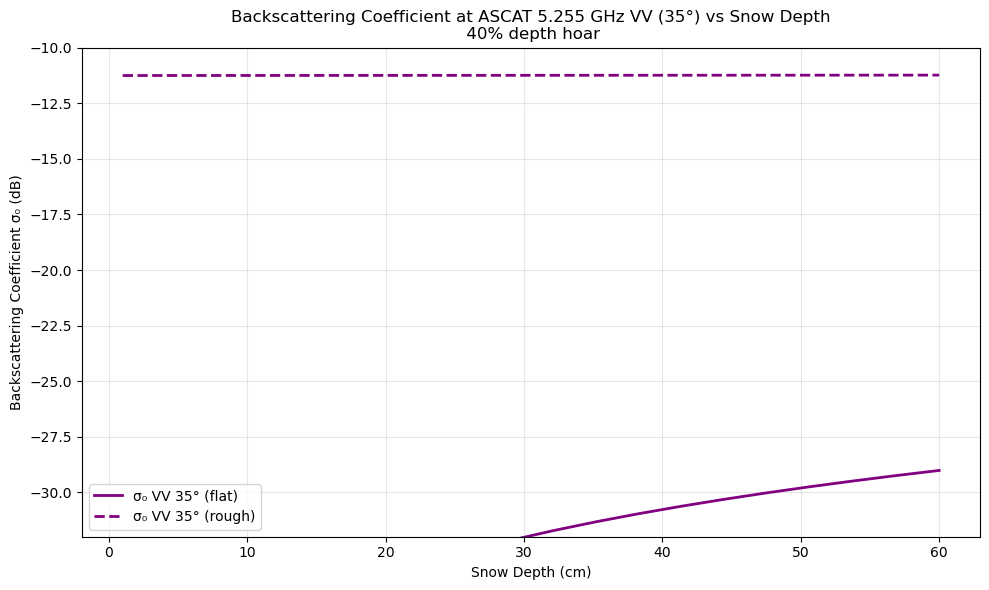

In [28]:
import numpy as np    
import matplotlib.pyplot as plt    
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body    
from smrt.inputs.make_medium import make_ice_column    
from smrt.core.interface import make_interface    
  
snow_depths = np.linspace(0.01, 0.6, 20)      
  
ocean = make_water_body(    
    temperature=272,    
    salinity=30 * PSU,    
    layer_thickness=1000    
)    
      
flat_interface = make_interface("flat")      
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)  
  
def create_snowpack(total_snow_depth, interface_type):    
    """Create snowpack with wind slab (top) then depth hoar, then interface"""    
          
    depth_hoar_thickness = total_snow_depth * 0.4  
    wind_slab_thickness = total_snow_depth * 0.6  
            
    wind_slab = make_snowpack(    
        thickness=[wind_slab_thickness],    
        microstructure_model="sticky_hard_spheres",    
        density=[350],    
        temperature=[265],    
        radius=[0.16e-3],   
        stickiness=[0.18],       
    )    
            
    depth_hoar = make_snowpack(    
        thickness=[depth_hoar_thickness],    
        microstructure_model="sticky_hard_spheres",    
        density=[200],    
        temperature=[265],    
        radius=[0.32e-3],    
        stickiness=[0.10],     
    )    
      
    multiyear_ice = make_ice_column(    
        ice_type="multiyear",    
        thickness=[2],    
        microstructure_model="sticky_hard_spheres",    
        density=[850],    
        temperature=[265],    
        radius=[0.1e-3],    
        stickiness=[0.2],    
        salinity=[1.2 * PSU],    
        brine_volume_fraction=0.05,    
        add_water_substrate=False,  
        interface=interface_type,    
    )    
            
    return wind_slab + depth_hoar + multiyear_ice + ocean 
    
snowpacks_flat = [create_snowpack(depth, flat_interface) for depth in snow_depths]    
snowpacks_rough = [create_snowpack(depth, rough_interface) for depth in snow_depths]    
    
sensor_ascat = sensor_list.ascat(theta=35)  
    
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=64))    
    
# Run with ASCAT sensor    
results_ascat_flat = model.run(sensor_ascat, snowpacks_flat,       
                               snowpack_dimension=('thickness', snow_depths))    
results_ascat_rough = model.run(sensor_ascat, snowpacks_rough,      
                                snowpack_dimension=('thickness', snow_depths))    
    
plt.figure(figsize=(10, 6))    
    

# Flat interface (solid line)
plt.plot(snow_depths * 100, results_ascat_flat.sigmaVV_dB(),    
        color='purple', linestyle='-', linewidth=2,    
        label=f"σ₀ VV 35° (flat)")    
    
# Rough interface (dashed line)
plt.plot(snow_depths * 100, results_ascat_rough.sigmaVV_dB(),    
        color='purple', linestyle='--', linewidth=2,    
        label=f"σ₀ VV 35° (rough)")    
    
plt.xlabel('Snow Depth (cm)')    
plt.ylabel('Backscattering Coefficient σ₀ (dB)')    
plt.title(f'Backscattering Coefficient at ASCAT 5.255 GHz VV (35°) vs Snow Depth\n 40% depth hoar')    
plt.ylim(-32, -10)  
plt.legend(loc='best')    
plt.grid(True, alpha=0.3)    
plt.tight_layout()    
plt.show()

## result from Soriot's paper 
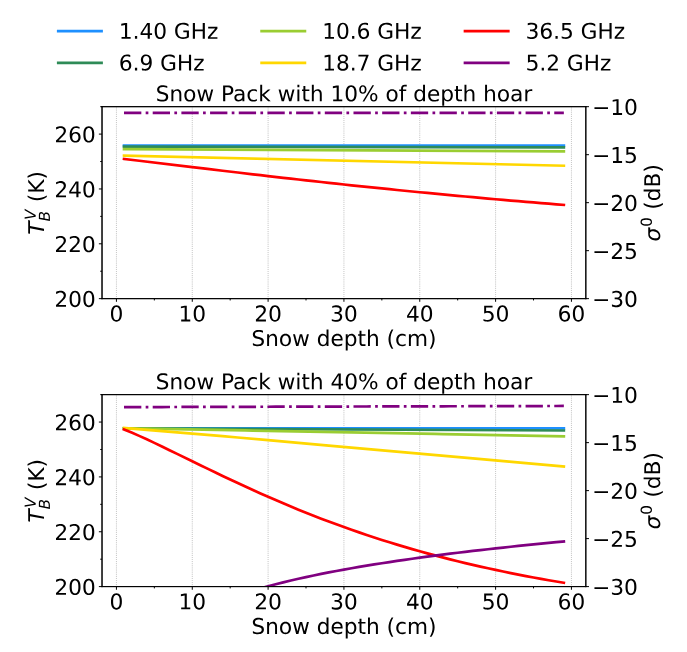

Simulated BTs are higher than those in the paper

# III. Sensitivity to snow melt
From early to mid-summer, the scattering effect observed over north of Greenland during winter disappears, both on passive and active observations. With the scattering effect no longer present at  high frequencies, the TBV difference between 1.4 and 36 GHz is reduced from ~ 60 K to ~ 20 K. This is due to the partial melting of the snow pack caused by the increasing surface temperatures. As a consequence, the dielectric property of the surface layer abruptly changes with the presence of liquid water in the snow cover. The main effect is an increase of the absorption by the top layer, which raises the emissivity and limits the impact of the signal coming from beneath. For the scatterometer, the presence of snow wetness strongly decreases  σ0 (Tedesco, 2007) due to the absorption of the incident wave. Snow melt can create melt ponds if a significant part of the snowpack melts, and the ponds are expected to be associated to low TB.
The folllowing simulation represent the effect of liquid water from 0 to 10% in the windslab, with 35cm of snow on top of 2m multi-year sea ice.

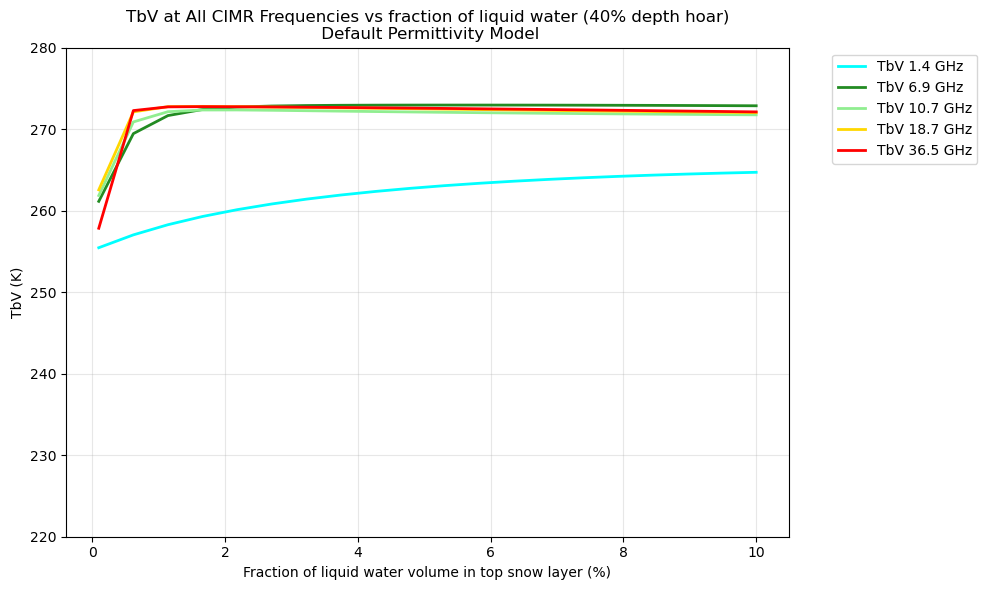

In [30]:
import numpy as np      
import matplotlib.pyplot as plt      
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body      
from smrt.inputs.make_medium import make_ice_column  
from smrt.interface.flat import Flat  
from smrt.core.interface import make_interface      
    
snow_thickness = 0.35    
liquid_fractions = np.linspace(0.001,0.1,20)     
      
ocean = make_water_body(      
    temperature=272,      
    salinity=30 * PSU,      
    layer_thickness=1000,  # semi-infinite  
)      
      
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)  
   
def create_snowpack(liq_fraction):      
    """Create snowpack with wind slab (top) then depth hoar, then interface"""      
     
    depth_hoar_thickness = snow_thickness * 0.4    
    wind_slab_thickness = snow_thickness * 0.6    
          

    wind_slab = make_snowpack(      
        thickness=[wind_slab_thickness],      
        microstructure_model="sticky_hard_spheres",      
        density=[350],     
        temperature=[273.15],      
        radius=[0.16e-3],    
        stickiness=[0.18],     
        liquid_water=[liq_fraction],  
    )           
  
    depth_hoar = make_snowpack(      
        thickness=[depth_hoar_thickness],      
        microstructure_model="sticky_hard_spheres",      
        density=[200],   
        temperature=[273.15],      
        radius=[0.32e-3],   
        stickiness=[0.10],      
    )      
          
    multiyear_ice = make_ice_column(      
        ice_type="multiyear",      
        thickness=[2],      
        microstructure_model="sticky_hard_spheres",      
        density=[850],    
        temperature=[265],      
        radius=[0.1e-3],      
        stickiness=[0.2],      
        salinity=[1.2* PSU],     
        add_water_substrate=False,  
        brine_volume_fraction=0.05,    
        interface=rough_interface,   
)       
          
    return wind_slab + depth_hoar + multiyear_ice + ocean     
      
# Create snowpacks for different liquid fractions      
snowpacks = [create_snowpack(liq) for liq in liquid_fractions]    
    
# Create sensor      
sensor_passive = sensor_list.cimr()  # CIMR passive sensor      
      
# Create model      
model = make_model("iba", "dort",rtsolver_options=dict(n_max_stream=128))   #VERY IMPORTANT TO HAVE 128 STREAM
      
# Run passive simulations      
results_passive_rough = model.run(sensor_passive, snowpacks)    
    
# Correct CIMR frequency colors      
frequency_colors = {    
    1.4135e9: 'cyan',         # 1.4 GHz    
    6.925e9: 'forestgreen',   # 6.9 GHz    
    10.65e9: 'lightgreen',    # 10.6 GHz    
    18.7e9: 'gold',           # 18.7 GHz    
    36.5e9: 'red'             # 36.5 GHz    
}    
          
plt.figure(figsize=(10, 6))      
      
# Plot TbV for all CIMR frequencies      
for channel_name, channel_config in sensor_passive.channel_map.items():      
    freq = channel_config['frequency']      
    color = frequency_colors.get(freq, '#333333')       
    if 'V' in channel_name:      
        plt.plot(liquid_fractions * 100, results_passive_rough.TbV(frequency=freq),      
                color=color, linestyle='-', linewidth=2,      
                label=f"TbV {freq/1e9:.1f} GHz")      
    
plt.xlabel('Fraction of liquid water volume in top snow layer (%)')      
plt.ylabel('TbV (K)')      
plt.title('TbV at All CIMR Frequencies vs fraction of liquid water (40% depth hoar)\n Default Permittivity Model')  
plt.ylim(220, 280)       
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      
plt.grid(True, alpha=0.3)      
plt.tight_layout()      
plt.show()

Active simulation : backscattering coeficient

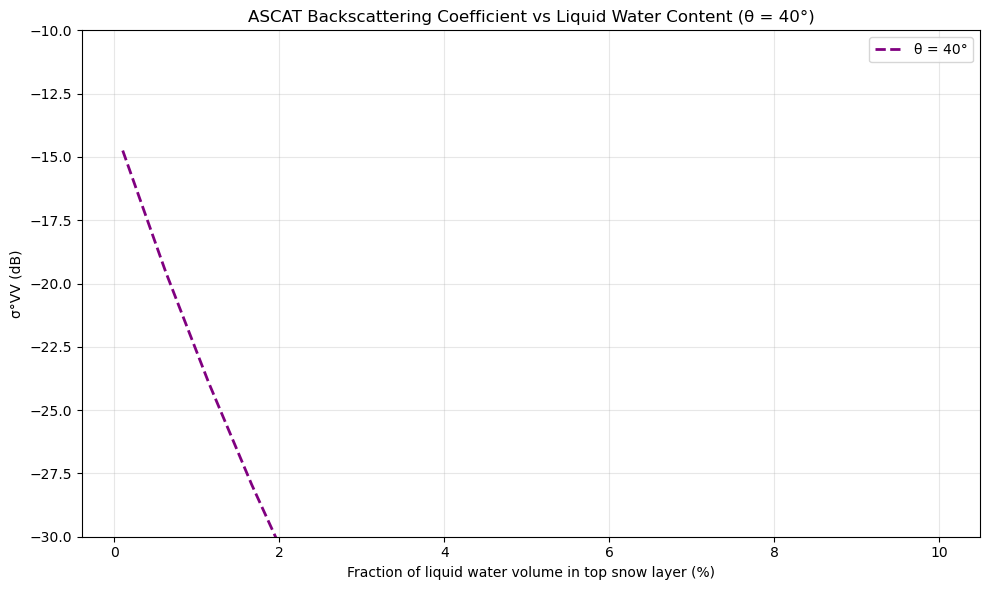

In [32]:
import numpy as np      
import matplotlib.pyplot as plt      
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body      
from smrt.inputs.make_medium import make_ice_column      
from smrt.core.interface import make_interface      
      
     
snow_thickness = 0.35      
liquid_fractions = np.linspace(0.001, 0.1, 20)      
      
  
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)    
         
def create_snowpack(liq_fraction):      
    """Create snowpack with wind slab (top) then depth hoar, then interface"""      
          
    depth_hoar_thickness = snow_thickness * 0.4      
    wind_slab_thickness = snow_thickness * 0.6      
 
    wind_slab = make_snowpack(      
        thickness=[wind_slab_thickness],      
        microstructure_model="sticky_hard_spheres",      
        density=[350],      
        temperature=[273.15],      
        radius=[0.16e-3],      
        stickiness=[0.18],      
        liquid_water=[liq_fraction],      
    )      
               
    depth_hoar = make_snowpack(      
        thickness=[depth_hoar_thickness],      
        microstructure_model="sticky_hard_spheres",      
        density=[200],      
        temperature=[273.15],      
        radius=[0.32e-3],      
        stickiness=[0.10],      
    )      
          
    multiyear_ice = make_ice_column(      
        ice_type="multiyear",      
        thickness=[2],      
        microstructure_model="sticky_hard_spheres",      
        density=[850],      
        temperature=[265],      
        radius=[0.1e-3],      
        stickiness=[0.2],      
        salinity=[1.2* PSU],      
        add_water_substrate=False,   
        brine_volume_fraction=0.05,      
        interface=rough_interface ,      
    )      
              
    return wind_slab + depth_hoar + multiyear_ice + ocean
      
# Create snowpacks for different liquid fractions      
snowpacks = [create_snowpack(liq) for liq in liquid_fractions]      
      
# Create ASCAT sensor with 40° viewing angle only      
sensor_ascat = sensor_list.ascat(theta=40)      
      
# Create model      
model = make_model("iba", "dort")      
      
# Run simulations      
results = model.run(sensor_ascat, snowpacks)      
      
# Create figure      
plt.figure(figsize=(10, 6))      
      
# Plot sigmaVV_dB for 40° only      
plt.plot(liquid_fractions * 100, results.sigmaVV_dB(theta=40),      
        linestyle='--', linewidth=2,      
        color='purple',      
        label=f"θ = 40°")      
      
plt.xlabel('Fraction of liquid water volume in top snow layer (%)')      
plt.ylabel('σ°VV (dB)')      
plt.title('ASCAT Backscattering Coefficient vs Liquid Water Content (θ = 40°)')      
plt.ylim(-30, -10)  # Set y-axis limits to (-30, -10)      
plt.legend()      
plt.grid(True, alpha=0.3)      
plt.tight_layout()      
plt.show()

## result from Soriot's paper 
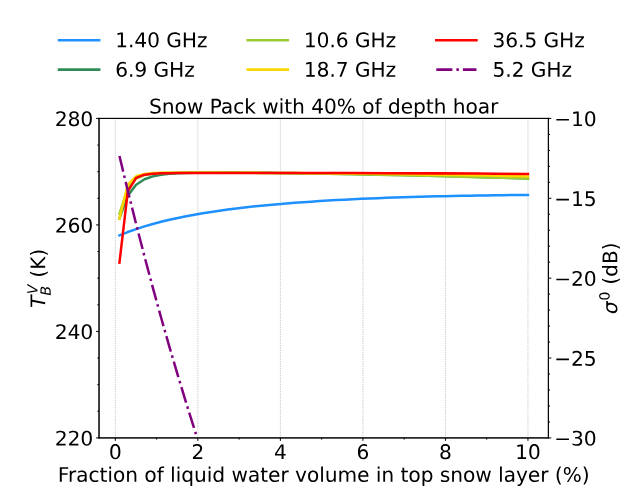

Very similar result

# IV. Superimposed ice thickness sensitivity
After the snowmelt period near the end of August, for different regions including north of Queen Elizabeth islands, a TB decrease of ~30 K at 36 GHz can be observed, which is a sign of scattering. Snow cover being usually melted, the scattering signal is unlikely resulting from the presence of depth hoar as in winter. This scattering signal could instead be explained by the presence of superimposed ice. Superimposed ice is created when water from snowmelt percolates down the snow cover and refreezes by contact with the sea ice. Superimposed ice is therefore different from freezing sea ice. It contains large air inclusions (~1 mm radius) that act as efficient scatterers at 18 and 36 GHz. TB depression due to the scattering effect of superimposed ice is of the same magnitude as the depth hoar scattering effect. The global presence of superimposed ice over the sea ice during late summer is hardly documented, as most studies focused on the regional-scale. The presence of scattering seems to be related to superimposed ice, which is wide spread throughout the Arctic at the end of summer.
The folllowing simulation represent the effect of superimposed ice depth, from 0 to 25cm, on top of 2m multi-year sea ice. Differents superimposed ice temperatures are simulated. 

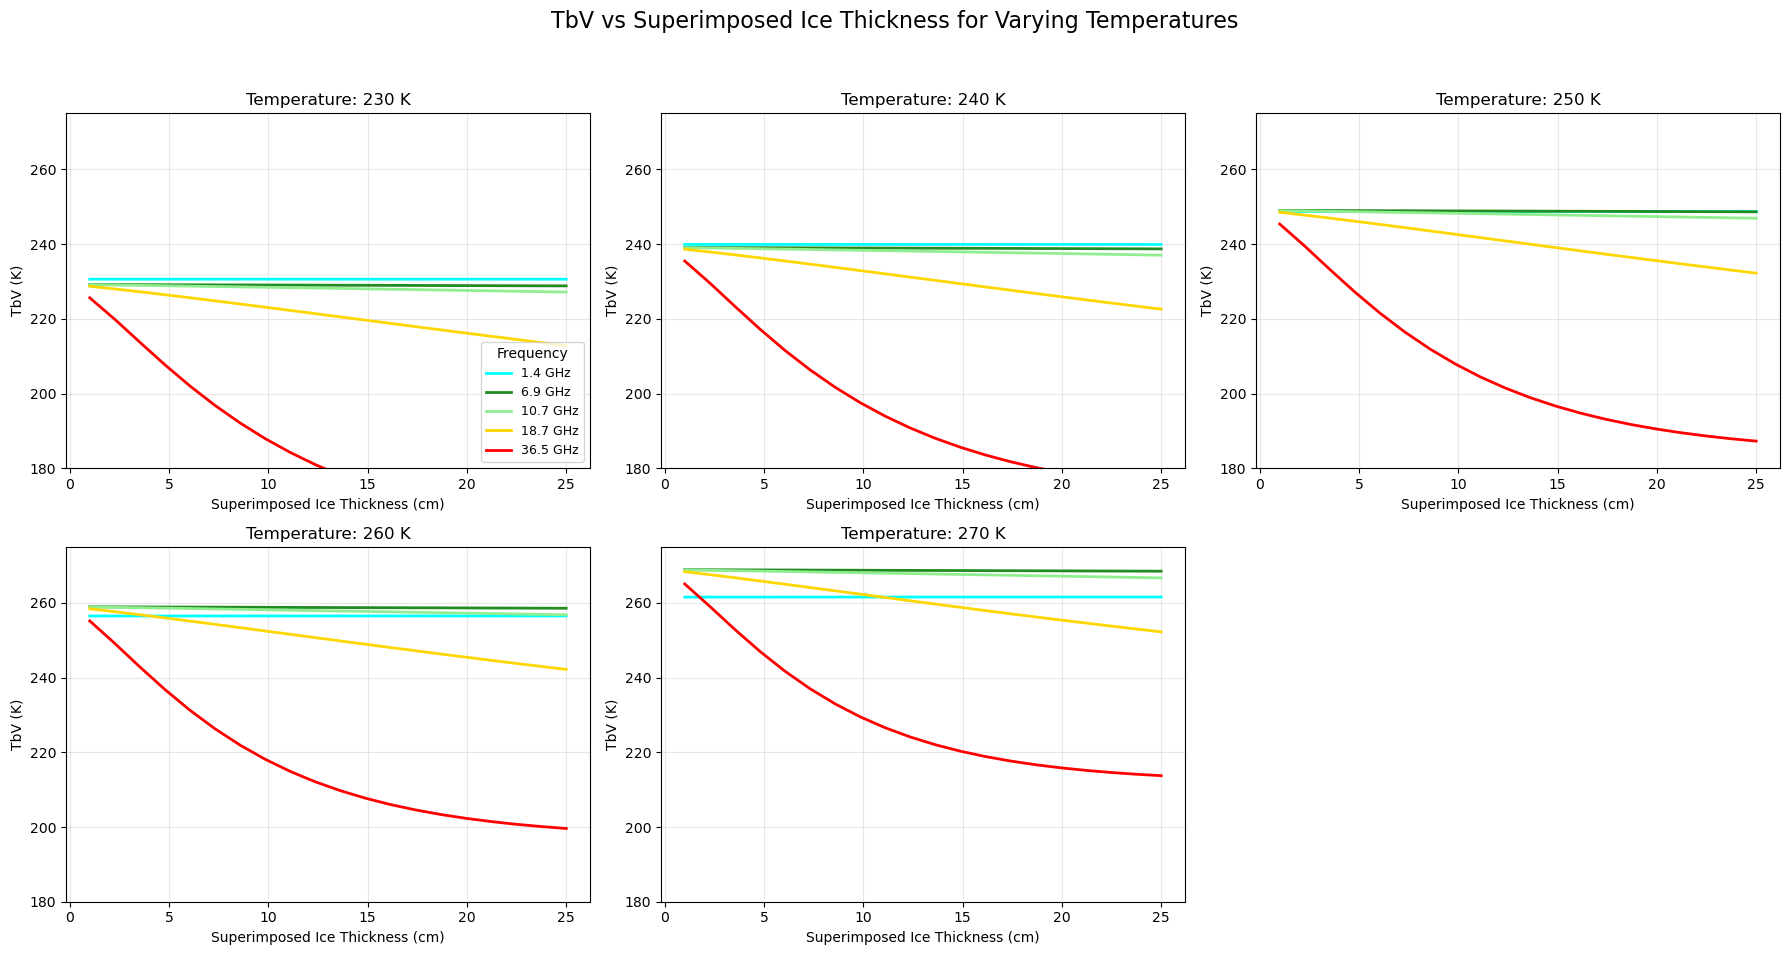

In [33]:
import numpy as np    
import matplotlib.pyplot as plt    
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body    
from smrt.inputs.make_medium import make_ice_column    
from smrt.core.interface import make_interface    

# 1. Setup parameters
superimposed_thicknesses = np.linspace(0.01, 0.25, 20)    
temperatures = [230, 240, 250, 260, 270]

# 2. Define simulation components
frequency_colors = {    
    1.4135e9: 'cyan',    
    6.925e9: 'forestgreen',    
    10.65e9: 'lightgreen',    
    18.7e9: 'gold',    
    36.5e9: 'red'    
}    

def create_snowpack_with_superimposed_ice(thickness, temp):    
    # Base multiyear ice
    multiyear_ice = make_ice_column(    
        ice_type="multiyear",    
        thickness=[2],    
        microstructure_model="sticky_hard_spheres",    
        density=[850],    
        temperature=[265],  # Matched to snowpack temp for consistency
        radius=[0.1e-3],    
        stickiness=[0.2],    
        salinity=[1.2 * PSU],    
        add_water_substrate=False,
        brine_volume_fraction=0.05,    
    )    
    
    superimposed_ice = make_ice_column(    
        ice_type="fresh",    
        thickness=[thickness],    
        microstructure_model="sticky_hard_spheres",    
        density=[850],    
        temperature=[temp], 
        radius=[1e-3],     
        stickiness=[0.2],    
        add_water_substrate=False    
    )    
    return superimposed_ice + multiyear_ice    

# 3. Initialize sensor and model
sensor_passive = sensor_list.cimr()    
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))    


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, temp in enumerate(temperatures):
    # Generate snowpacks for this specific temperature
    snowpacks = [create_snowpack_with_superimposed_ice(thick, temp) for thick in superimposed_thicknesses]    
    
    # Run model
    results = model.run(sensor_passive, snowpacks)    
    
    ax = axes[idx]
    
    # Plot results
    for channel_name, channel_config in sensor_passive.channel_map.items():    
        freq = channel_config['frequency']    
        color = frequency_colors.get(freq)    
        if 'V' in channel_name:    
            ax.plot(superimposed_thicknesses * 100, results.TbV(frequency=freq),    
                    color=color, linestyle='-', linewidth=2,    
                    label=f"{freq/1e9:.1f} GHz")    
    
    ax.set_xlabel('Superimposed Ice Thickness (cm)')    
    ax.set_ylabel('TbV (K)')    
    ax.set_title(f'Temperature: {temp} K')    
    ax.set_ylim(180, 275)    
    ax.grid(True, alpha=0.3)
    
    # Only show legend on the first plot to save space
    if idx == 0:
        ax.legend(title="Frequency", loc='lower right', fontsize=9)

# Hide the empty 6th subplot
if len(temperatures) < len(axes):
    axes[-1].axis('off')

plt.suptitle('TbV vs Superimposed Ice Thickness for Varying Temperatures', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## result from Soriot's paper 
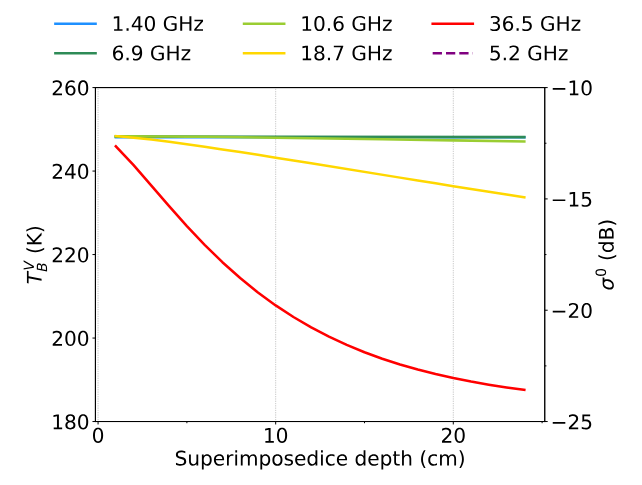

With a temperature of superimposed ice of 250K, the simulation obtained is the same than the one form the paper. 